In [43]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import datetime

# Point this to YOUR generated split folder
REPO_ROOT = Path.cwd().parent
BASE_DIR = REPO_ROOT / "data" / "generated" / "train"
MANIFEST = BASE_DIR / "manifests" / "train_manifest.jsonl"

print("Manifest exists:", MANIFEST.exists())
print("Modified:", datetime.datetime.fromtimestamp(MANIFEST.stat().st_mtime))
print("Size:", MANIFEST.stat().st_size)

print("unique labels:", np.unique(y))
print("num transitions:", int(np.sum(y[1:] != y[:-1])))

Manifest exists: True
Modified: 2026-03-04 21:19:04.522984
Size: 2699717
unique labels: [0 1]
num transitions: 6


In [37]:
def load_manifest_rows(manifest_path: Path, max_rows: int | None = None):
    rows = []
    with manifest_path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            rows.append(json.loads(line))
    return rows

rows = load_manifest_rows(MANIFEST, max_rows=200)  # load first 200 for quick browsing
print("Loaded rows:", len(rows))

# Pick one example
row = rows[190]
row["ex_id"], row["clean_audio_path"], row["labels_path"]

Loaded rows: 200


('train_0000190',
 'clean_audio\\train_0000190.npy',
 'labels\\train_0000190_y.npy')

In [39]:
sr = int(row["sr"])
x = np.load(BASE_DIR / row["clean_audio_path"])
y = np.load(BASE_DIR / row["labels_path"])

hop_s = float(row["frame_params"]["hop_ms"]) / 1000.0

print("ex_id:", row["ex_id"])
print("audio:", x.shape, x.dtype, "sec:", x.size / sr)
print("labels:", y.shape, y.dtype, "label duration sec:", y.size * hop_s)
print("speech frame %:", 100 * y.mean())

print("Speech frames:", np.sum(y))
print("Non-speech frames:", len(y) - np.sum(y))

ex_id: train_0000190
audio: (258156,) float32 sec: 16.13475
labels: (1611,) uint8 label duration sec: 16.11
speech frame %: 74.487895716946
Speech frames: 1200
Non-speech frames: 411


In [40]:
sil = row.get("silences", [])
sil_samples = sum(s["end"] - s["start"] for s in sil)
sil_sec = sil_samples / sr
total_sec = x.size / sr
print("Inserted silence sec:", sil_sec)
print("Inserted silence %:", 100 * sil_sec / total_sec)
print("Num silence segments:", len(sil))

Inserted silence sec: 4.13475
Inserted silence %: 25.626365453446756
Num silence segments: 4


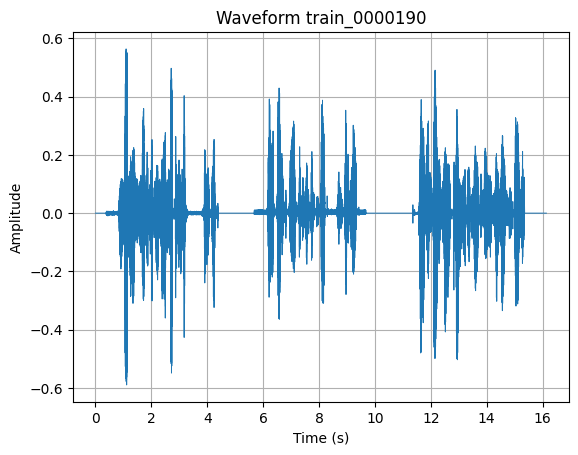

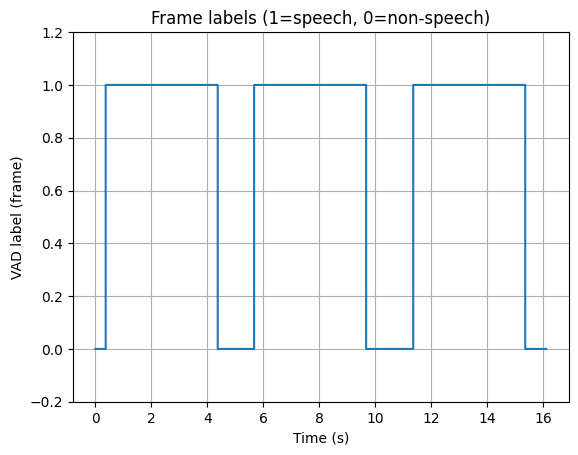

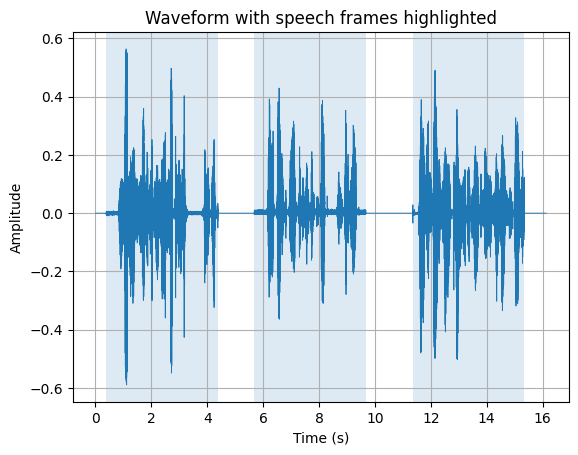

In [41]:
def plot_wave_and_labels(x, y, sr, hop_s, title="", max_sec=None):
    if max_sec is not None:
        x = x[: int(max_sec * sr)]
        y = y[: int(max_sec / hop_s)]

    t_audio = np.arange(x.size) / sr
    t_frames = np.arange(y.size) * hop_s

    # Waveform
    plt.figure()
    plt.plot(t_audio, x, linewidth=0.7)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Waveform {title}")
    plt.grid(True)
    plt.show()

    # Labels
    plt.figure()
    plt.step(t_frames, y, where="post")
    plt.ylim(-0.2, 1.2)
    plt.xlabel("Time (s)")
    plt.ylabel("VAD label (frame)")
    plt.title("Frame labels (1=speech, 0=non-speech)")
    plt.grid(True)
    plt.show()

    # Overlay highlight speech frames
    plt.figure()
    plt.plot(t_audio, x, linewidth=0.6)
    for k, lab in enumerate(y):
        if lab == 1:
            t0 = k * hop_s
            t1 = (k + 1) * hop_s
            plt.axvspan(t0, t1, alpha=0.15)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Waveform with speech frames highlighted")
    plt.grid(True)
    plt.show()

plot_wave_and_labels(x, y, sr, hop_s, title=row["ex_id"], max_sec=25)

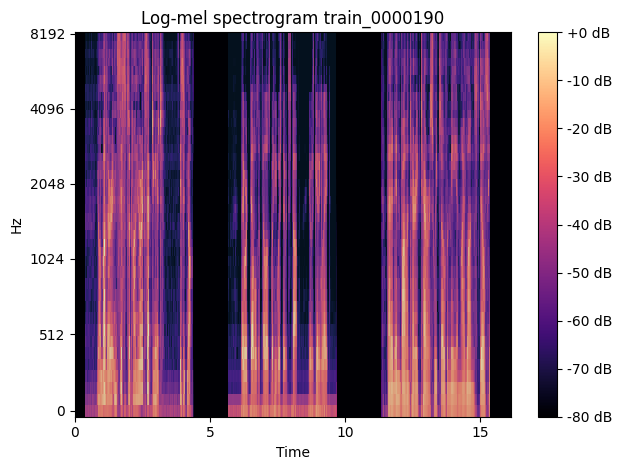

In [42]:
def plot_logmel_with_labels(x, y, sr, hop_s, title="", max_sec=25, n_mels=40):
    x = x[: int(max_sec * sr)]
    y = y[: int(max_sec / hop_s)]

    # Use your same framing defaults: 25ms win (400 samples), 10ms hop (160 samples)
    win_length = 400
    hop_length = 160

    S = librosa.feature.melspectrogram(
        y=x,
        sr=sr,
        n_fft=win_length,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure()
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Log-mel spectrogram {title}")

    # overlay labels
    for k, lab in enumerate(y):
        if lab == 1:
            t0 = k * hop_s
            t1 = (k + 1) * hop_s
            plt.axvspan(t0, t1, alpha=0.15)

    plt.tight_layout()
    plt.show()

plot_logmel_with_labels(x, y, sr, hop_s, title=row["ex_id"], max_sec=25)